In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df= pd.read_csv('hearing_test.csv')
df

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1
...,...,...,...
4995,73.0,3.9,0
4996,57.0,33.9,1
4997,49.0,34.5,1
4998,38.0,46.4,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [26]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [27]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='test_result', ylabel='age'>

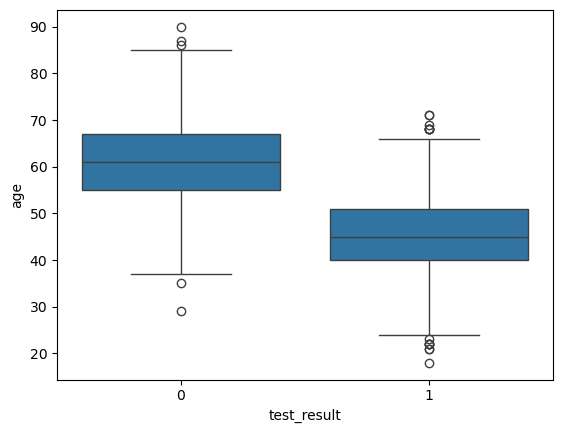

In [28]:
sns.boxplot(x='test_result',y='age',data=df)

<Axes: xlabel='test_result', ylabel='physical_score'>

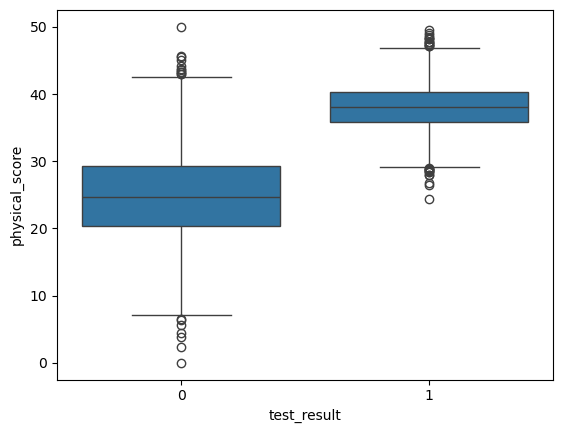

In [29]:
sns.boxplot(x='test_result',y='physical_score',data=df)

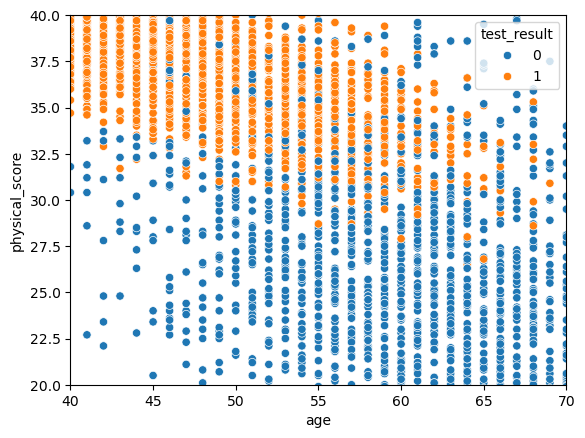

In [64]:
sns.scatterplot(data=df,x='age',y='physical_score',hue='test_result')
plt.ylim(20,40)
plt.xlim(40,70)
plt.show()

In [31]:
df.corr()

,age,physical_score,test_result
age,1.000000,-0.782146,-0.683171
physical_score,-0.782146,1.000000,0.792716
test_result,-0.683171,0.792716,1.000000


<Axes: xlabel='physical_score', ylabel='test_result'>

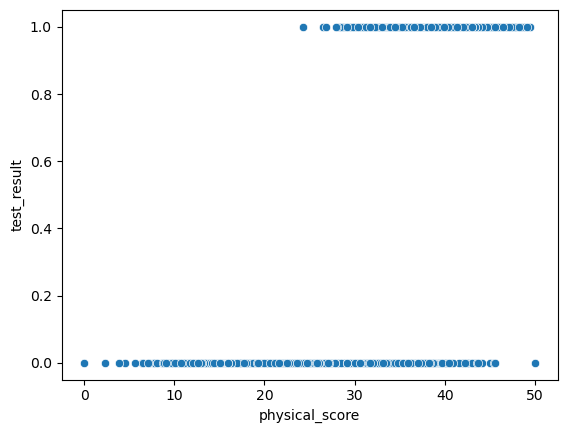

In [32]:
sns.scatterplot(data=df,x='physical_score',y='test_result')

### Train | Test Split

In [33]:
X=df.drop('test_result',axis=1)
y=df['test_result']

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [35]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=101)

In [36]:
sc= StandardScaler()

In [37]:
sc_X_train= sc.fit_transform(X_train)
sc_X_test= sc.transform(X_test)

### Logistic Regression Model

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
log_model= LogisticRegression()

In [40]:
log_model.fit(sc_X_train,y_train)

LogisticRegression()

In [45]:
y_pred= log_model.predict(sc_X_test)

In [72]:
y_proba= log_model.predict_proba(sc_X_test)
y_proba

array([[0.02436668, 0.97563332],
       [0.02672574, 0.97327426],
       [0.9893468 , 0.0106532 ],
       ...,
       [0.02396838, 0.97603162],
       [0.94905149, 0.05094851],
       [0.22356825, 0.77643175]])

In [43]:
log_model.coef_

array([[-0.9039212 ,  3.48681952]])

### Model performance on classification tasks

In [84]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, RocCurveDisplay,auc, precision_recall_curve, PrecisionRecallDisplay

In [47]:
y

0       1
1       1
2       0
3       0
4       1
       ..
4995    0
4996    1
4997    1
4998    1
4999    1
Name: test_result, Length: 5000, dtype: int64

In [48]:
y_pred.shape

(1000,)

In [49]:
accuracy_score(y_test,y_pred)

0.917

In [50]:
confusion_matrix(y_pred,y_test)

array([[332,  27],
       [ 56, 585]])

In [52]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       388
           1       0.91      0.96      0.93       612

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.92      0.92      1000



In [53]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.92      0.86      0.89       388\n           1       0.91      0.96      0.93       612\n\n    accuracy                           0.92      1000\n   macro avg       0.92      0.91      0.91      1000\nweighted avg       0.92      0.92      0.92      1000\n'

In [54]:
type(classification_report(y_test,y_pred))

str

In [55]:
X_train.iloc[11]

age               53.0
physical_score    30.6
Name: 4240, dtype: float64

In [62]:
y_train.iloc[11]

np.int64(0)

In [57]:
X_train.iloc[11].values

array([53. , 30.6])

In [59]:
X_train.iloc[11].values.reshape(1,-1)

array([[53. , 30.6]])

In [68]:
log_model.predict_proba(sc.transform(X_train.iloc[11].values.reshape(1,-1)))

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.62675098, 0.37324902]])

In [61]:
log_model.predict(X_train.iloc[11].values.reshape(1,-1))

array([1])

In [65]:
log_model.predict([[62,32.5]])

array([1])

In [66]:
sc.transform([[70,32.5]])

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 1.61397331, -0.02446366]])

In [67]:
log_model.predict_proba(sc.transform([[70,32.5]]))

C:\Users\Taneja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.74376817, 0.25623183]])

### Evaluating ROC

In [71]:
help(roc_curve)

Help on function roc_curve in module sklearn.metrics._ranking:

roc_curve(
    y_true,
    y_score,
    *,
    pos_label=None,
    sample_weight=None,
    drop_intermediate=True
)
    Compute Receiver operating characteristic (ROC).

    Note: this implementation is restricted to the binary classification task.

    Read more in the :ref:`User Guide <roc_metrics>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True binary labels. If labels are not either {-1, 1} or {0, 1}, then
        pos_label should be explicitly given.

    y_score : array-like of shape (n_samples,)
        Target scores, can either be probability estimates of the positive
        class, confidence values, or non-thresholded measure of decisions
        (as returned by "decision_function" on some classifiers).
        For :term:`decision_function` scores, values greater than or equal to
        zero should indicate the positive class.

    pos_label : int, float, bool or str, 

In [73]:
y_proba

array([[0.02436668, 0.97563332],
       [0.02672574, 0.97327426],
       [0.9893468 , 0.0106532 ],
       ...,
       [0.02396838, 0.97603162],
       [0.94905149, 0.05094851],
       [0.22356825, 0.77643175]])

In [74]:
y_proba[:,1]

array([9.75633321e-01, 9.73274262e-01, 1.06531992e-02, 9.98106993e-01,
       2.58627368e-02, 1.00414283e-02, 9.26144591e-01, 9.82584563e-01,
       3.00683958e-03, 9.67451965e-01, 9.18551742e-01, 9.89781141e-01,
       9.92726432e-01, 6.25711783e-02, 9.99880198e-01, 9.32728798e-01,
       1.15167559e-02, 9.97122886e-01, 9.99437621e-01, 3.58735951e-03,
       1.22594999e-01, 8.71470239e-01, 4.70273310e-01, 9.66441751e-01,
       6.20669490e-01, 4.76750178e-01, 9.60757072e-01, 9.81199404e-01,
       8.88360122e-02, 9.99690667e-01, 9.54003431e-01, 9.97773967e-01,
       9.82428302e-01, 9.93669826e-01, 9.55848408e-01, 3.09918694e-02,
       9.34473634e-01, 9.71983337e-01, 1.19894462e-02, 9.54738885e-01,
       9.93598608e-01, 6.18831927e-01, 6.42727545e-01, 4.30101968e-01,
       3.14346751e-04, 9.37711186e-01, 9.33431847e-01, 9.83578217e-01,
       9.44223507e-01, 8.70448445e-01, 8.22564812e-01, 3.85996066e-01,
       3.97862232e-01, 1.27040816e-01, 9.95483875e-01, 2.05350547e-01,
      

In [75]:
scores=y_proba[:,1]

In [77]:
fpr, tpr, thresholds = roc_curve(y_test,scores)

In [82]:
roc_auc = auc(fpr, tpr)

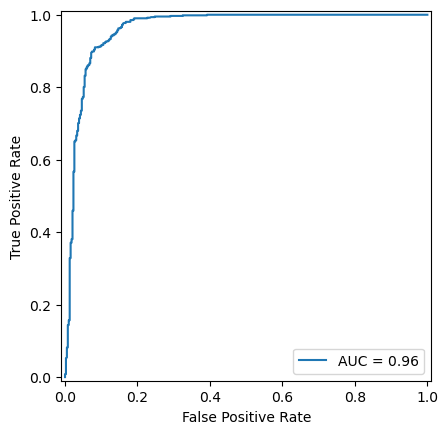

In [83]:
RocCurveDisplay(fpr=fpr, tpr=tpr,roc_auc=roc_auc).plot()

In [85]:
help(precision_recall_curve)

Help on function precision_recall_curve in module sklearn.metrics._ranking:

precision_recall_curve(
    y_true,
    y_score=None,
    *,
    pos_label=None,
    sample_weight=None,
    drop_intermediate=False,
    probas_pred='deprecated'
)
    Compute precision-recall pairs for different probability thresholds.

    Note: this implementation is restricted to the binary classification task.

    The precision is the ratio ``tp / (tp + fp)`` where ``tp`` is the number of
    true positives and ``fp`` the number of false positives. The precision is
    intuitively the ability of the classifier not to label as positive a sample
    that is negative.

    The recall is the ratio ``tp / (tp + fn)`` where ``tp`` is the number of
    true positives and ``fn`` the number of false negatives. The recall is
    intuitively the ability of the classifier to find all the positive samples.

    The last precision and recall values are 1. and 0. respectively and do not
    have a corresponding thresh

In [86]:
precision, recall, thresholds = precision_recall_curve(y_test,scores)

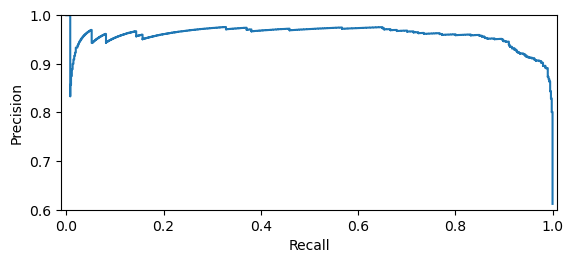

In [88]:
PrecisionRecallDisplay(precision=precision,recall=recall).plot()
plt.ylim(0.6,1)
plt.show()